# Notebook 01 — Exploratory Data Analysis: AfriSenti Amharic

**Project**: Amharic Sentiment Analysis Platform  
**Author**: Eyob Nebyou  
**Dataset**: AfriSenti-SemEval 2023 — Amharic Subset  
**Goal**: Understand the dataset before any modeling.

---

## What We're Answering

1. What does the dataset look like? (size, splits, columns)
2. How balanced are the sentiment classes?
3. What does Amharic text look like in this dataset?
4. How long are the tweets? (text length distribution)
5. What are the most common words per sentiment class?
6. What challenges does Amharic NLP present?

---

In [2]:
# ── Imports ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import os
warnings.filterwarnings('ignore')

from datasets import load_dataset
from collections import Counter

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 200)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load the Dataset

In [3]:
from datasets import load_dataset

print('Loading AfriSenti Amharic dataset...')
dataset = load_dataset(
    'masakhane/afrisenti',
    'amh'
)
print(dataset)

Loading AfriSenti Amharic dataset...


DatasetDict({
    train: Dataset({
        features: ['tweet', 'label'],
        num_rows: 5984
    })
    validation: Dataset({
        features: ['tweet', 'label'],
        num_rows: 1497
    })
    test: Dataset({
        features: ['tweet', 'label'],
        num_rows: 1999
    })
})


In [4]:
# ── Convert to pandas DataFrames ──────────────────────────────
train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

print(f'Train set:      {train_df.shape}')
print(f'Validation set: {val_df.shape}')
print(f'Test set:       {test_df.shape}')
print(f'Total samples:  {len(train_df) + len(val_df) + len(test_df):,}')
print(f'\nColumns: {train_df.columns.tolist()}')
print(f'\nSample rows:')
print(train_df.head())

Train set:      (5984, 2)
Validation set: (1497, 2)
Test set:       (1999, 2)
Total samples:  9,480

Columns: ['tweet', 'label']

Sample rows:
                                                                                                               tweet  \
0                                                         Tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ   
1                                             ይሄው ነው አይደል የእውቀትሽ ጥግ....በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም....ደሞ ራስሽን አታስገምቺ   
2                                                                                ዘገበ ይባላል? ሌላ የሚባል ነገር ካለ አንተዉ ንገረን!   
3  ?? ድሮ በዘመነ ኮዳክ ፎቶ ቤት ፍላሹ ፏ ሲል አይናችን ተጨፍኖ እንዳይወጣ የምንቸክለውን ነገር አስታወሰኝ ???? ምን ሆኖ ነው ግን? ከሗላ ያለው ቴዲ ሁሉ ፊቱን አዞረ እኮ ??   
4                                                                                                     ዠልጥ?? ???? ገገማ   

      label  
0  negative  
1  negative  
2  negative  
3  negative  
4  negative  


In [5]:
# ── Label mapping ──────────────────────────────────────────────
print('Unique labels in train:', train_df['label'].unique())
print('Label dtype:', train_df['label'].dtype)

label_map = {0: 'positive', 1: 'negative', 2: 'neutral'}
if train_df['label'].dtype in ['int64', 'int32']:
    train_df['sentiment'] = train_df['label'].map(label_map)
    val_df['sentiment'] = val_df['label'].map(label_map)
    test_df['sentiment'] = test_df['label'].map(label_map)
else:
    train_df['sentiment'] = train_df['label']
    val_df['sentiment'] = val_df['label']
    test_df['sentiment'] = test_df['label']

print('\nSentiment value counts (train):')
print(train_df['sentiment'].value_counts())

Unique labels in train: <ArrowStringArray>
['negative', 'neutral', 'positive']
Length: 3, dtype: str
Label dtype: str

Sentiment value counts (train):
sentiment
neutral     3104
negative    1548
positive    1332
Name: count, dtype: int64


## 2. Class Distribution — Is the Dataset Balanced?

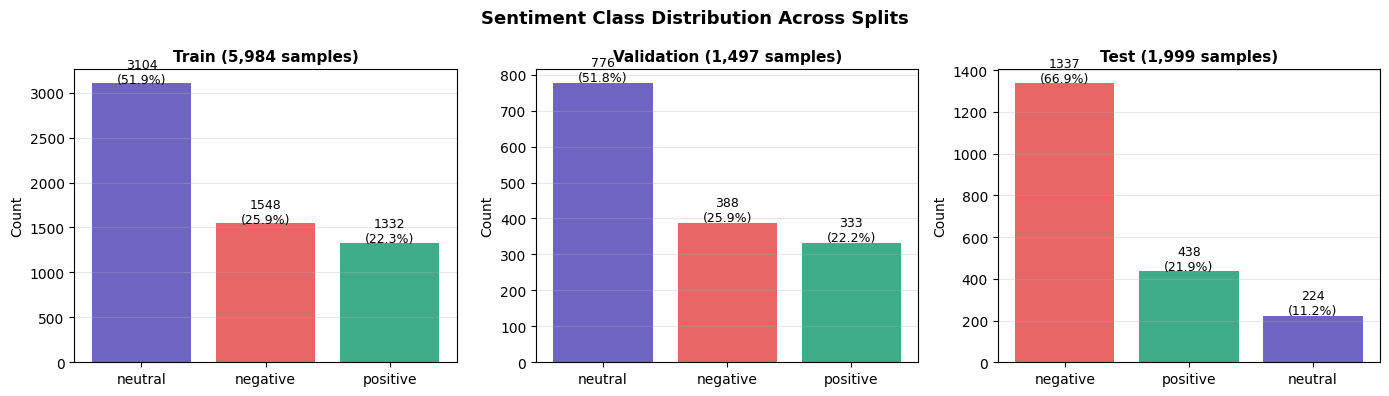

Saved: 01_class_distribution.png


In [6]:
# ── Class distribution across all splits ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'positive': '#1D9E75', 'negative': '#E24B4A', 'neutral': '#534AB7'}

for ax, (split_name, split_df) in zip(axes, [
    ('Train', train_df),
    ('Validation', val_df),
    ('Test', test_df)
]):
    counts = split_df['sentiment'].value_counts()
    bar_colors = [colors.get(l, '#888') for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=bar_colors, alpha=0.85)
    ax.set_title(f'{split_name} ({len(split_df):,} samples)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        pct = val / len(split_df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({pct:.1f}%)', ha='center', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Sentiment Class Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_class_distribution.png')

The dataset exhibits significant class imbalance and distribution shift across splits. The Train and Validation sets share a matching distribution dominated by neutral samples (51.9% and 51.8%), followed by negative (25.9% and 25.9%) and positive (22.3% and 22.2%). In contrast, the Test set experiences a severe distribution shift: negative sentiment dominates at 66.9% (1,337 samples), positive accounts for 21.9% (438 samples), and neutral drops to just 11.2% (224 samples).


## 3. Sample Amharic Tweets

In [7]:
# ── Show sample tweets per class ──────────────────────────────
print('Sample tweets from each sentiment class:\n')
for sentiment in ['positive', 'negative', 'neutral']:
    print(f'=== {sentiment.upper()} ===')
    samples = train_df[train_df['sentiment'] == sentiment]['tweet'].head(3)
    for i, tweet in enumerate(samples, 1):
        print(f'  {i}. {tweet}')
    print()

Sample tweets from each sentiment class:

=== POSITIVE ===
  1. እኔ በአማርኛ ጥሩ ነኝ
  2. ዛሬ ጁመዓ በወሎ ኮንቦልቻ የተደረካ ከባድ መልክት ያለው የቃውሞ ሰልፍ ብልፅግና ፓርቲ ብልፅግናችሁን አሳዩን
  3. ጥበበኛው የፍቅር አስተማሪ ቴዲ አፍሮ

=== NEGATIVE ===
  1. Tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ
  2. ይሄው ነው አይደል የእውቀትሽ ጥግ....በሰሚ ሰሚ ከምትናገሪ ለምን ታሪክ አታነቢም....ደሞ ራስሽን አታስገምቺ
  3. ዘገበ ይባላል? ሌላ የሚባል ነገር ካለ አንተዉ ንገረን!

=== NEUTRAL ===
  1. የሆነ ነገር መጥፎ ነገር ተናግሬያለሁ?!
  2. ልዩ የተፈጥሮ ገፅታ   *****  የምስራቅ አፍሪካ የውሃ ማማ ጮቄ
  3. ብ/ጄ አሳምነው ጽጌ ከምክትል ጠ/ሚ ደመቀ ጋር በሱዳን ጉብኝት አልበሽር ያሉትን ለተመስገን እንደነገረው....  ኢትዮጵያ ለእኛ ጥሩ ጎረቤታችን ናት፤ ከህወሓት ጋር ግን ቤተሰብ ነን።



## 4. Text Length Analysis

In [8]:
# ── Character and word length distributions ───────────────────
train_df['char_length'] = train_df['tweet'].str.len()
train_df['word_count'] = train_df['tweet'].str.split().str.len()

print('Text length statistics (train):')
print(train_df[['char_length', 'word_count']].describe().round(2))

Text length statistics (train):
       char_length  word_count
count      5984.00     5984.00
mean         71.45       14.42
std          36.18        7.09
min           1.00        1.00
25%          39.00        8.00
50%          71.00       14.00
75%         106.00       21.00
max         146.00       37.00


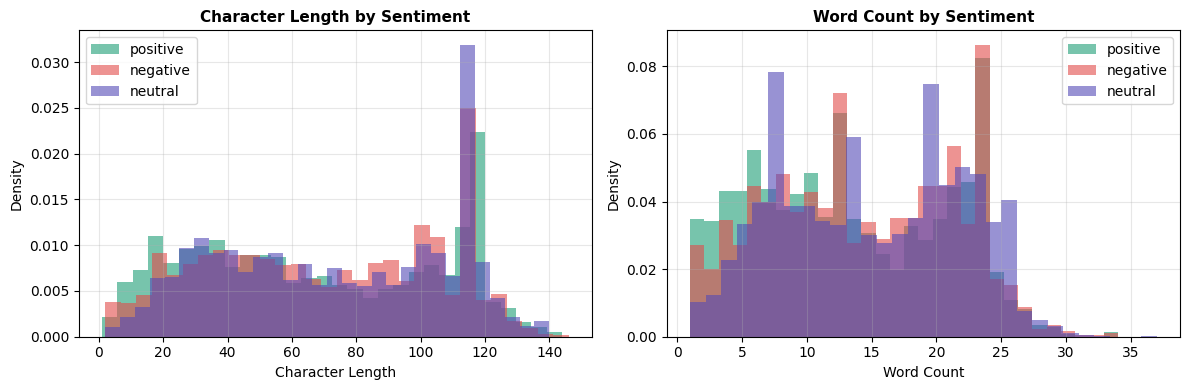

Saved: 01_text_length_distribution.png


In [9]:
# ── Length distribution by sentiment ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_list = ['#1D9E75', '#E24B4A', '#534AB7']
sentiments = ['positive', 'negative', 'neutral']

for ax, metric, title in zip(
    axes,
    ['char_length', 'word_count'],
    ['Character Length', 'Word Count']
):
    for sentiment, color in zip(sentiments, colors_list):
        subset = train_df[train_df['sentiment'] == sentiment][metric]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=sentiment, density=True)
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.set_title(f'{title} by Sentiment', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/01_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_text_length_distribution.png')

## 5. Most Common Words Per Sentiment

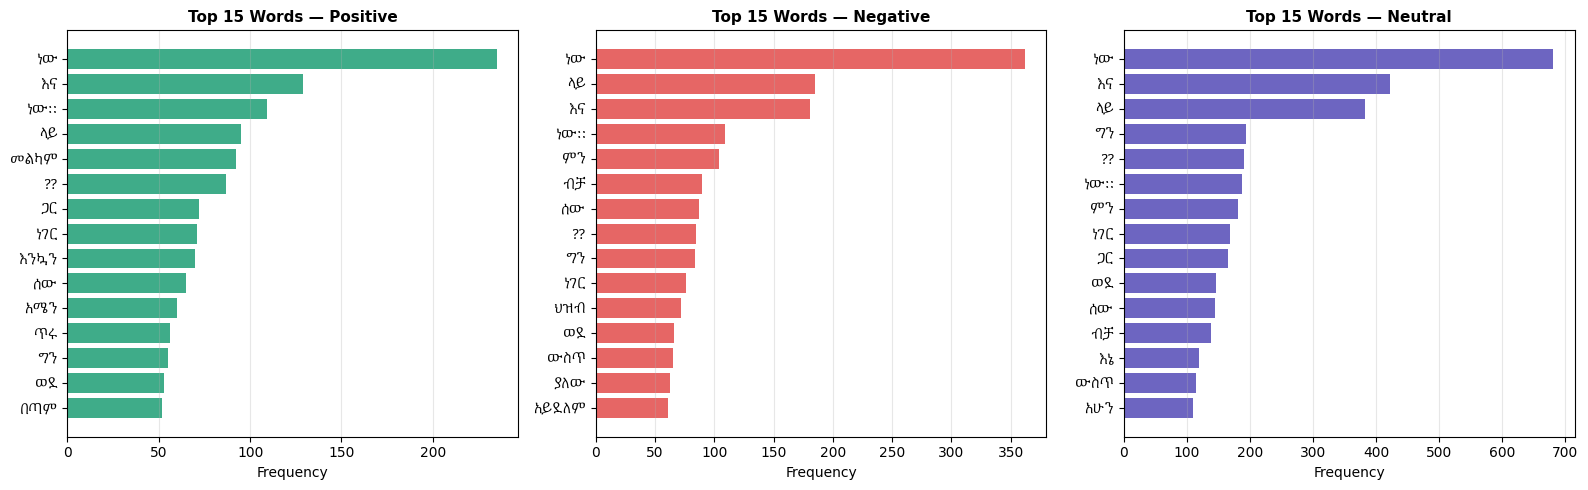

Saved: 01_top_words_per_sentiment.png


In [10]:
from collections import Counter
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# Dynamically search system font files for Ethiopic support
ethiopic_candidates = [
    'Kefa',
    'Noto Sans Ethiopic',
    'NotoSansEthiopic',
    'Abyssinica SIL',
]
ethiopic_font_path = None

for f in fm.fontManager.ttflist:
  if any(name.lower() in f.name.lower() for name in ethiopic_candidates):
    ethiopic_font_path = f.fname
    break

# Create FontProperties if found, otherwise fall back to system default
if ethiopic_font_path:
  ethiopian_prop = fm.FontProperties(fname=ethiopic_font_path, size=10)
else:
  ethiopian_prop = fm.FontProperties(family='sans-serif', size=10)

# Top words per sentiment class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sentiment, color in zip(axes, sentiments, colors_list):
  tweets = train_df[train_df['sentiment'] == sentiment]['tweet']
  all_words = ' '.join(tweets).split()
  all_words = [w for w in all_words if len(w) > 1]
  word_counts = Counter(all_words).most_common(15)
  words, counts = zip(*word_counts)

  ax.barh(range(len(words)), counts, color=color, alpha=0.85)
  ax.set_yticks(range(len(words)))
  ax.set_yticklabels(words, fontproperties=ethiopian_prop)

  ax.set_title(
      f'Top 15 Words — {sentiment.capitalize()}',
      fontsize=11,
      fontweight='bold',
  )
  ax.set_xlabel('Frequency')
  ax.grid(axis='x', alpha=0.3)
  ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    '../reports/01_top_words_per_sentiment.png', dpi=150, bbox_inches='tight'
)
plt.show()
print('Saved: 01_top_words_per_sentiment.png')

## 6. Amharic NLP Challenges

In [11]:
# ── Check for mixed scripts (Amharic + Latin) ─────────────────
def has_amharic(text):
    return bool(re.search(r'[\u1200-\u137F]', str(text)))

def has_latin(text):
    return bool(re.search(r'[a-zA-Z]', str(text)))

train_df['has_amharic'] = train_df['tweet'].apply(has_amharic)
train_df['has_latin'] = train_df['tweet'].apply(has_latin)
train_df['is_mixed'] = train_df['has_amharic'] & train_df['has_latin']

pure_amharic = (train_df['has_amharic'] & ~train_df['has_latin']).sum()
mixed = train_df['is_mixed'].sum()

print('Script analysis (train set):')
print(f'  Pure Amharic (Ethiopic only): {pure_amharic:,} ({pure_amharic/len(train_df):.1%})')
print(f'  Mixed (Amharic + Latin):      {mixed:,} ({mixed/len(train_df):.1%})')

print('\nSample mixed-script tweets:')
mixed_samples = train_df[train_df['is_mixed']]['tweet'].head(3)
for i, tweet in enumerate(mixed_samples, 1):
    print(f'  {i}. {tweet}')

Script analysis (train set):
  Pure Amharic (Ethiopic only): 5,361 (89.6%)
  Mixed (Amharic + Latin):      621 (10.4%)

Sample mixed-script tweets:
  1. Tesfaye ለካስ ጭብል ለብሰሽ የፕሮፌሰርን ፎቶ ለጥፈክ እልም ያልክ ባዳ ነክ እፈር ትንሽ
  2. የነዚህን አይነት ወሬ አራጋቢ ነው!  Do you get me!!?
  3. Arte በገናው ምድር በዚህ ሲያስተክዘን አመሸ


In [12]:
# ── Check for URLs, mentions, hashtags ────────────────────────
train_df['has_url'] = train_df['tweet'].str.contains(r'http\S+', regex=True)
train_df['has_mention'] = train_df['tweet'].str.contains(r'@\w+', regex=True)
train_df['has_hashtag'] = train_df['tweet'].str.contains(r'#\w+', regex=True)

print('Noise analysis (train set):')
print(f'  Tweets with URLs:     {train_df["has_url"].sum():,} ({train_df["has_url"].mean():.1%})')
print(f'  Tweets with mentions: {train_df["has_mention"].sum():,} ({train_df["has_mention"].mean():.1%})')
print(f'  Tweets with hashtags: {train_df["has_hashtag"].sum():,} ({train_df["has_hashtag"].mean():.1%})')

Noise analysis (train set):
  Tweets with URLs:     0 (0.0%)
  Tweets with mentions: 0 (0.0%)
  Tweets with hashtags: 0 (0.0%)


## 7. Save Processed DataFrames

In [13]:
# Add length features to val and test too
val_df['char_length'] = val_df['tweet'].str.len()
val_df['word_count'] = val_df['tweet'].str.split().str.len()
test_df['char_length'] = test_df['tweet'].str.len()
test_df['word_count'] = test_df['tweet'].str.split().str.len()
val_df['sentiment'] = val_df['label']
test_df['sentiment'] = test_df['label']

In [14]:
# ── Save all splits for use in next notebooks ──────────────────
os.makedirs('../data/processed', exist_ok=True)

train_df.to_parquet('../data/processed/train_raw.parquet', index=False)
val_df.to_parquet('../data/processed/val_raw.parquet', index=False)
test_df.to_parquet('../data/processed/test_raw.parquet', index=False)

print('Saved:')
print(f'  train_raw.parquet — {train_df.shape}')
print(f'  val_raw.parquet   — {val_df.shape}')
print(f'  test_raw.parquet  — {test_df.shape}')
print('\n✅ EDA complete. Proceed to Notebook 02 for preprocessing.')

Saved:
  train_raw.parquet — (5984, 11)
  val_raw.parquet   — (1497, 5)
  test_raw.parquet  — (1999, 5)

✅ EDA complete. Proceed to Notebook 02 for preprocessing.


## 8. Summary & Findings

| Item | Detail |
|---|---|
| Total samples | 9,480 |
| Train / Val / Test | 5,984 / 1,497 / 1,999 |
| Class balance | Neutral 51.9%, Negative 25.9%, Positive 22.3% |
| Most common sentiment | Neutral |
| Avg tweet length (words) | 14.42 |
| Mixed script tweets | 621 (10.4%) |
| Tweets with URLs | 0 (0.0%) |

**Key NLP challenges identified**:
- Dataset is imbalanced — neutral dominates at 51.9%. We will use macro F1 to evaluate fairly across all classes
- 10.4% of tweets mix Amharic and Latin script — preprocessing must handle both
- Manual inspection reveals label noise in neutral class — some tweets appear positive or negative but are labeled neutral. This is a known challenge in low-resource NLP annotation
- No URLs found — less noise to clean than expected
- Amharic morphology is complex — one root word has many forms
- Dataset appears pre-cleaned — no URLs, mentions, or hashtags found. Preprocessing will focus on Ethiopic normalization and mixed script handling.

**Next steps (Day 3 — Preprocessing)**:
- Remove mentions (@user) and hashtags
- Normalize Ethiopic characters
- Handle mixed script text
- Save clean dataset ready for modeling